# Sprint 13 - Proyecto

## 0. Importación de librerías

In [46]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.dummy import DummyRegressor

## 1. Preparación los datos

### 1.1 Abre los archivos y examina los datos.

In [2]:
df_train = pd.read_csv('/datasets/gold_recovery_train.csv')
df_test = pd.read_csv('/datasets/gold_recovery_test.csv')
df_full = pd.read_csv('/datasets/gold_recovery_full.csv')

In [3]:
df_train.info()
print(df_train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


In [4]:
df_test.info()
print(df_test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   object 
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_clea

In [5]:
df_full.info()
print(df_full.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                22716 non-null  object 
 1   final.output.concentrate_ag                         22627 non-null  float64
 2   final.output.concentrate_pb                         22629 non-null  float64
 3   final.output.concentrate_sol                        22331 non-null  float64
 4   final.output.concentrate_au                         22630 non-null  float64
 5   final.output.recovery                               20753 non-null  float64
 6   final.output.tail_ag                                22633 non-null  float64
 7   final.output.tail_pb                                22516 non-null  float64
 8   final.output.tail_sol                               22445 non-null  float64


Tenemos dataframes con muchas columnas, lo cual dificulta la lectura directa, a continuación revisaré algunas características mediante código para tener una mejor visibilidad de la información

In [6]:
columnas_train = df_train.columns
columnas_test = df_test.columns
columnas_full = df_full.columns
print(f'df_train tiene: {len(columnas_train)} columnas')
print(f'df_test tiene: {len(columnas_test)} columnas')
print(f'df_full tiene: {len(columnas_full)} columnas')

df_train tiene: 87 columnas
df_test tiene: 53 columnas
df_full tiene: 87 columnas


Con esto comprobamos lo que se comenta en la descripción del proyecto, el conjunto 'test' tiene menos datos que el resto. Los datos 'test' tampoco contienen objetivos. El dataset fuente contiene los conjuntos de entrenamiento con **TODAS** las características.

La descripción del proyecto también menciona que los datos se indexan con la fecha y hora (columna 'date'), por lo que usaré esta información para cambiar el index de los dataframes, así podré comparar el conjunto 'test' con el 'full' y de esa manera podré completar la información faltante en el punto 1.3.

In [7]:
df_train = df_train.set_index('date')
df_test = df_test.set_index('date')
df_full = df_full.set_index('date')

Compruebo que no hayan filas donde todos los valores estén ausentes.

In [8]:
ausentes_train = df_train.isna().all(axis = 1).sum()
ausentes_test = df_test.isna().all(axis=1).sum()
ausentes_full = df_full.isna().all(axis=1).sum()
print(ausentes_train)
print(ausentes_test)
print(ausentes_full)

0
0
0


#### Conclusión del análisis preliminar de los datos

Como ya sabíamos por la descripción del proyecto, hay una diferencia de datos entre los archivos de entrenamiento y de prueba, vemos que la diferencia son 34 columnas, en el punto 1.3 analizaré cuales son esas columnas diferentes. En cuanto al tipo de datos de las columnas y viendo los datos inspeccionados, no veo alguna que deba ser modificada. Realicé el cambio de index de los conjuntos usando la fecha, esto me permitirá hacer comparaciones entre los conjuntos si es necesario.

### 1.2 Comprobación del cálculo de recuperación

Recordando la formula presentada en la información previa del proyecto, la formula de recuperación es:

Recuperación = {[C x (F - T)] / [F x (C - T)]} x 100

Donde: 
    C es la proporción de oro en el concentrado de la etapa analizada;
    F es la proporción de oro en la alimentación de esa etapa;
    T es la proporción de oro en las colas de esa etapa.

Para este caso, las columnas que contienen los datos que necesitamos son:
    C: rougher.output.concentrate_au;
    F: rougher.input.feed_au
    T: rougher.output.tail_au

In [9]:
c = df_train['rougher.output.concentrate_au']
f = df_train['rougher.input.feed_au']
t = df_train['rougher.output.tail_au']
recovery_calc = ((c * (f -t)) / (f * (c - t))) * 100
print(recovery_calc.describe())

count    1.457700e+04
mean              NaN
std               NaN
min              -inf
25%      7.965104e+01
50%      8.521533e+01
75%      9.019726e+01
max               inf
dtype: float64


Puedo ver que 'recovery_calc' tiene valores infinitos tanto positivos como negativos, en el punto 1.4 tomaré en cuenta este hallazgo para mi procesamiento. Hago la comparación entre los datos calculados y los existentes en los datos, para esto restaré ambos valores y calcularé el EAM.

In [10]:
comparacion = df_train['rougher.output.recovery'] - recovery_calc
eam = comparacion.abs().mean()
print(eam)

9.303415616264301e-15


El EAM es 9.30e-15, practicamente igual a 0. Si vemos los datos estadísticos calculados arriba de 'recovery_calc' vemos que la mediana tiene un valor de 8.52e+01 (85.2) y el tercer cuartil de 90.1, al compararlos con el EAM calculado noto una diferencia grande, por lo que puedo afirmar que los datos calculados son prácticamente iguales a los contenidos en los datos originales, estadísticamente no hay diferencia en usar un conjunto o el otro para futuros cálculos.

### 1.3 Análisis de características no disponibles en el conjunto de prueba

Inicio viendo que columnas son las que NO están presentes en el conjunto de prueba pero SI están presentes en los datos completos

In [11]:
columnas = set(columnas_full) - set(columnas_test)
print(len(columnas))
print(columnas)

34
{'primary_cleaner.output.tail_pb', 'final.output.recovery', 'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.tail_ag', 'rougher.calculation.sulfate_to_au_concentrate', 'primary_cleaner.output.tail_au', 'final.output.concentrate_sol', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_pb', 'final.output.tail_ag', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'rougher.calculation.au_pb_ratio', 'rougher.output.concentrate_au', 'final.output.tail_sol', 'secondary_cleaner.output.tail_au', 'primary_cleaner.output.tail_sol', 'final.output.tail_pb', 'secondary_cleaner.output.tail_ag', 'secondary_cleaner.output.tail_pb', 'rougher.output.concentrate_pb', 'final.output.concentrate_pb', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'rougher.output.concentrate_ag', 'final.output.concentrate_au', 'final.output.concentrate_ag', 'rougher.output.tail_sol', 'rougher.output.tail_au', 'final.output.tail_

A primera vista no identifico algún patrón en las columnas vistas, por lo que realizaré filtrados para encontrar algún patrón, iniciando por filtrar por 'stage'

In [12]:
rougher_cols = [col for col in columnas if 'rougher' in col]
print(rougher_cols)
print(f'Número de columnas para "rougher_cols": {len(rougher_cols)}')

primary_cleaner_cols = [col for col in columnas if 'primary_cleaner' in col]
print(primary_cleaner_cols)
print(f'Número de columnas para "primary_cleaner_cols": {len(primary_cleaner_cols)}')

secondary_cleaner_cols = [col for col in columnas if 'secondary_cleaner' in col]
print(secondary_cleaner_cols)
print(f'Número de columnas para "secondary_cleaner_cols": {len(secondary_cleaner_cols)}')

final_cols = [col for col in columnas if 'final' in col]
print(final_cols)
print(f'Número de columnas para "final_cols": {len(final_cols)}')

['rougher.calculation.sulfate_to_au_concentrate', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'rougher.calculation.au_pb_ratio', 'rougher.output.concentrate_au', 'rougher.output.concentrate_pb', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'rougher.output.concentrate_ag', 'rougher.output.tail_sol', 'rougher.output.tail_au', 'rougher.output.concentrate_sol', 'rougher.output.tail_pb', 'rougher.output.tail_ag', 'rougher.output.recovery']
Número de columnas para "rougher_cols": 13
['primary_cleaner.output.tail_pb', 'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_au', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_pb', 'primary_cleaner.output.tail_sol']
Número de columnas para "primary_cleaner_cols": 8
['secondary_cleaner.output.tail_au', 'secondary_cleaner.output.tail_ag', 'secondary_cleaner.output.tail_pb', 'secondary_cleaner.output.tail_sol']


Veo que la mayoría de las columnas contienen '.output' en su nombre, también veo algunos '.calculation', procedo a hacer el filtrado y conteo

In [13]:
output_cols = [col for col in columnas if 'output' in col]
print(output_cols)
print(f'Número de columnas con "output" en su nombre: {len(output_cols)}')

calculation_cols = [col for col in columnas if 'calculation' in col]
print(calculation_cols)
print(f'Número de columnas con "output" en su nombre: {len(calculation_cols)}')


['primary_cleaner.output.tail_pb', 'final.output.recovery', 'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_au', 'final.output.concentrate_sol', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_pb', 'final.output.tail_ag', 'rougher.output.concentrate_au', 'final.output.tail_sol', 'secondary_cleaner.output.tail_au', 'primary_cleaner.output.tail_sol', 'final.output.tail_pb', 'secondary_cleaner.output.tail_ag', 'secondary_cleaner.output.tail_pb', 'rougher.output.concentrate_pb', 'final.output.concentrate_pb', 'rougher.output.concentrate_ag', 'final.output.concentrate_au', 'final.output.concentrate_ag', 'rougher.output.tail_sol', 'rougher.output.tail_au', 'final.output.tail_au', 'secondary_cleaner.output.tail_sol', 'rougher.output.concentrate_sol', 'rougher.output.tail_pb', 'rougher.output.tail_ag', 'rougher.output.recovery']
Número de columnas con "output" en su no

Veo que las columnas que no están disponibles en el conjunto de datos de prueba son los referentes a las salidas de los procesos (output) y a los cálculos (calculation). Mi suposición es que los datos de salida no estan en el dataset porque no son datos que se tengan de inmediato al terminar el proceso, se requieren pruebas de laboratorio para determinar las concentraciones de los diferentes elementos, y esto lleva tiempo, creo que los datos disponibles en el conjunto de prueba fueron tomados al momento de la producción, antes de tener los resultados de laboratorio. Para los datos de cálculos, estos dependen de los resultados de las concentraciones, por lo tanto tampoco fue posible calcularlos.

### 1.4 Preprocesamiento de datos.

Como lo dice la descripción, el conjunto de datos 'full' tiene más información que el conjunto 'test', como ya lo establecí anteriormente, las columnas ausentes seguramente existen porque son datos que se obtienen después. Por ahora, lo que voy a revisar es si en las columnas existentes existen datos ausentes en los conjuntos 'train' y 'full' y si la cantidad en las columnas de interés es la misma

In [14]:
columnas_test = df_test.columns
filas_test = df_test.index
ausentes_test = (df_test.isna().sum()).sum()
ausentes_full = (df_full.loc[filas_test, columnas_test].isna().sum()).sum()

print(f'Número total de ausentes en el conjunto "test": {ausentes_test}')
print(f'Número total de ausentes en el conjunto "full": {ausentes_full}')

Número total de ausentes en el conjunto "test": 2360
Número total de ausentes en el conjunto "full": 2360


No hay diferencia, lo que quiere decir que las columnas que contiene el conjunto 'test' tienen la misma cantidad de datos NaN en ambos conjuntos. Anteriormente realizando el cálculo de 'recuperación' me encontré con valores +-inf, revisaré que valor tiene el conjunto 'train' en esas filas

In [15]:
filas_inf = recovery_calc[np.isinf(recovery_calc)].index

print(df_train.loc[filas_inf, 'rougher.output.recovery'])

date
2016-03-02 21:00:00   NaN
2016-03-02 22:00:00   NaN
2016-05-01 04:59:59   NaN
2016-05-22 10:59:59   NaN
2016-05-22 11:59:59   NaN
2016-05-22 12:59:59   NaN
2016-05-22 13:59:59   NaN
2016-05-22 14:59:59   NaN
2016-05-22 15:59:59   NaN
2016-05-22 16:59:59   NaN
2016-07-01 01:59:59   NaN
2017-01-13 01:59:59   NaN
2017-01-25 08:59:59   NaN
2017-03-06 13:59:59   NaN
2017-03-06 14:59:59   NaN
2017-05-08 13:59:59   NaN
2017-05-08 18:59:59   NaN
2017-05-11 08:59:59   NaN
2017-06-15 12:59:59   NaN
2017-07-05 15:59:59   NaN
2017-07-05 16:59:59   NaN
2018-01-03 13:59:59   NaN
2018-01-03 20:59:59   NaN
2018-01-03 21:59:59   NaN
2018-01-03 22:59:59   NaN
2018-01-04 01:59:59   NaN
2018-01-04 02:59:59   NaN
2018-01-11 23:59:59   NaN
2018-01-26 11:59:59   NaN
2018-01-26 12:59:59   NaN
Name: rougher.output.recovery, dtype: float64


Veo que en los datos 'train' los inf se pasaron como NaN, posiblemente debido a que el cálculo no se puede realizar. Antes de hacer algo con estos valores NaN haré una revisión en los datos para asegurar que no haya datos inf

In [16]:
print(np.isinf(df_train).sum().sum())
print(np.isinf(df_test).sum().sum())
print(np.isinf(df_full).sum().sum())

0
0
0


No existen datos inf en ninguno de los dfs. Por ahora trabajaré únicamente en los conjuntos 'test' y 'train' ya que son los que usaré para entrenar y validar el modelo. El siguiente paso es asegurar que los datos no tengan NaN, esto debido a que el modelo puede tener errores al entrenarse con un dataset 'sucio'. Primero revisaré cual es la proporción de datos NaN en el conjunto 'train' para cada columna para evaluar el posible impacto de cambiar los datos NaN por su media o mediana:

In [17]:
datos_train = (df_train.isna().sum()) + (df_train.count()) 
proporcion_train = (df_train.isna().sum()) / datos_train
print(f'Estadística de proporción de datos NaN por columna del conjunto df_train: \n{proporcion_train.describe()}')

Estadística de proporción de datos NaN por columna del conjunto df_train: 
count    86.000000
mean      0.020911
std       0.035621
min       0.000000
25%       0.003440
50%       0.005042
75%       0.017156
max       0.152610
dtype: float64


Consideré solo el conjunto 'train' debido a que, en una situación real, el conjunto 'test' tiene datos 'futuros' que no necesariamente están disponibles en la etapa de creación y entrenamiento del modelo, por lo que no consideraré los datos estadísticos del conjunto 'test'. Partiendo de los resultados obtenidos, vemos que, en general, la proporción de datos NaN en las columnas es pequeña, de menos del 1.7% en el 75% de las columnas, hay una diferencia considerable entre la media (2%) y la mediana (0.5%), viendo el valor máximo de 15.2% puedo decir que hay columnas un una cantidad atípicamente grande de valores NaN, seguramente columnas de cálculos por lo visto anteriormente. Con todo esto en mente, considero seguro poder hacer la sustitución de los valores NaN sin alterar gravemente el dataset. Antes de decidir si la sustitución la haré por la media o la mediana de cada columna, revisaré las columnas con mayor número de datos NaN 

In [18]:
print(proporcion_train.sort_values(ascending=False).head(10))

rougher.output.recovery               0.152610
rougher.output.tail_ag                0.133452
rougher.output.tail_sol               0.133393
rougher.output.tail_au                0.133393
secondary_cleaner.output.tail_sol     0.117794
rougher.input.floatbank11_xanthate    0.112930
final.output.recovery                 0.090214
primary_cleaner.input.sulfate         0.077521
primary_cleaner.input.depressant      0.074852
rougher.calculation.au_pb_ratio       0.073665
dtype: float64


El resultado es que la columna de 'rougher.output.recovery' es la columna con mayor número de datos NaN con 15.2%, otra observación es que 6 columnas del top 10 son del proceso 'rougher', donde vimos que al calcular la recuperación encontramos valores de +-inf, lo que indica que hay valores atípicos. Estadísticamente hablando para este tipo de casos es más conveniente utilizar la mediana para hacer la sustitución de los datos, por lo que primero hago el calculo de la mediana de cada columna y luego hago la sustitución tanto en el conjunto 'train' como en 'test'

In [19]:
medianas = df_train.median()
columnas_nan = df_train.columns[df_train.isna().sum() > 0]

for col in columnas_nan:
    df_train[col] = df_train[col].fillna(medianas[col])
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(medianas[col])

print(df_test.isna().sum().sum())
print(df_train.isna().sum().sum())

0
0


### Conclusión de la preparacion de los datos

Durante la preparación de los datos se cargaron y examinaron los tres conjuntos (train, test, full), indexándolos por fecha para facilitar su comparación. Se confirmó que test carece de 34 columnas presentes en train/full, todas correspondientes a parámetros de tipo output y calculation, lo cual es consistente con el hecho de que estos valores dependen de análisis de laboratorio no disponibles al momento de capturar los datos de proceso. La fórmula de recuperación proporcionada se validó recalculándola manualmente y comparándola contra rougher.output.recovery, obteniendo un EAM de 9.3e-15 — prácticamente cero — lo que confirma la validez del dato original. Los valores infinitos que resultaron del cálculo manual correspondieron a NaN en los datos originales, y se confirmó que ninguno de los tres conjuntos contiene valores infinitos reales. Se evaluó la proporción de NaN por columna en train (menor al 1.7% en el 75% de las columnas, máximo 15.2% en rougher.output.recovery, concentrados principalmente en el proceso rougher) y se imputaron con la mediana de cada columna —calculada únicamente sobre train para no introducir fuga de información— tanto en train como en test. 

## 2. Análisis de datos

### 2.1. Concentración de metales (Au, Ag, Pb) a lo largo del proceso

Voy a calcular las medias de las concentraciones de cada metal en cada proceso para después graficarlas y compararlas.

In [20]:
procesos = ['input', 'rougher', 'primary', 'final']

media_oro_input = df_full['rougher.input.feed_au'].mean()
media_oro_rougher = df_full['rougher.output.concentrate_au'].mean()
media_oro_primary = df_full['primary_cleaner.output.concentrate_au'].mean()
media_oro_final = df_full['final.output.concentrate_au'].mean()
medias_oro = pd.Series([media_oro_input, media_oro_rougher, media_oro_primary, media_oro_final], procesos)

media_plata_input = df_full['rougher.input.feed_ag'].mean()
media_plata_rougher = df_full['rougher.output.concentrate_ag'].mean()
media_plata_primary = df_full['primary_cleaner.output.concentrate_ag'].mean()
media_plata_final = df_full['final.output.concentrate_ag'].mean()
medias_plata = pd.Series([media_plata_input, media_plata_rougher, media_plata_primary, media_plata_final], procesos)

media_plomo_input = df_full['rougher.input.feed_pb'].mean()
media_plomo_rougher = df_full['rougher.output.concentrate_pb'].mean()
media_plomo_primary = df_full['primary_cleaner.output.concentrate_pb'].mean()
media_plomo_final = df_full['final.output.concentrate_pb'].mean()
medias_plomo = pd.Series([media_plomo_input, media_plomo_rougher, media_plomo_primary, media_plomo_final], procesos)

medias_general = pd.DataFrame({
    'Oro (Au)': medias_oro,
    'Plata (Ag)': medias_plata,
    'Plomo (Pb)': medias_plomo,
})
print(medias_general)

          Oro (Au)  Plata (Ag)  Plomo (Pb)
input     7.565838    8.065715    3.305676
rougher  17.879538   10.874484    6.900646
primary  29.212289    7.691652    8.921110
final    40.001172    4.781559    9.095308


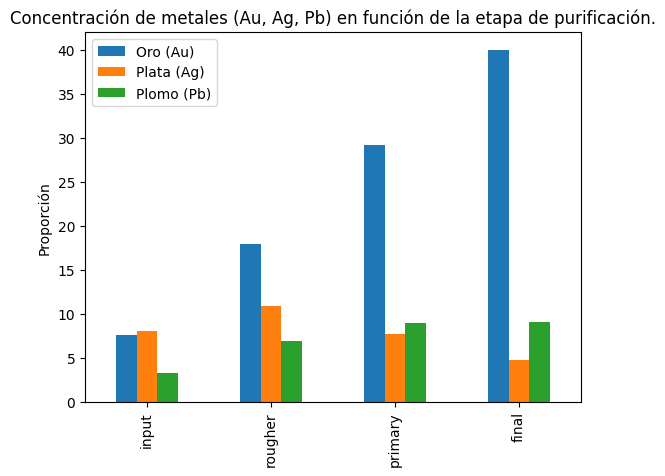

In [21]:
medias_general.plot(
    kind = 'bar',
    title = 'Concentración de metales (Au, Ag, Pb) en función de la etapa de purificación.',
    ylabel = 'Proporción'
)
plt.legend()
plt.show()

### Conclusiones sobre la concentración de los metales a lo largo del proceso

Gracias a la gráfica podemos ver de una manera muy visual como la proporción de oro va aumentando conforme (inicia en 7.56 y termina en 40) avanza el proceso (mientras más procesada la mezcla, mayor concentración de oro contiene). 
Para el plomo vemos un ligero aumento, desde 3.3 a 9.09 y para la plata se nota un comportamiento diferente, incia con un valor de 8.06, para el primer proceso aumenta a 10.87 y luego desciende para tener un valor final de 4.78. 

### 2.2. Comparación de distribución de tamaño de las partículas

Realizaré la comparación de la distribución de tamaños para los conjuntos 'test' y 'train', iniciando con el proceso 'rougher'

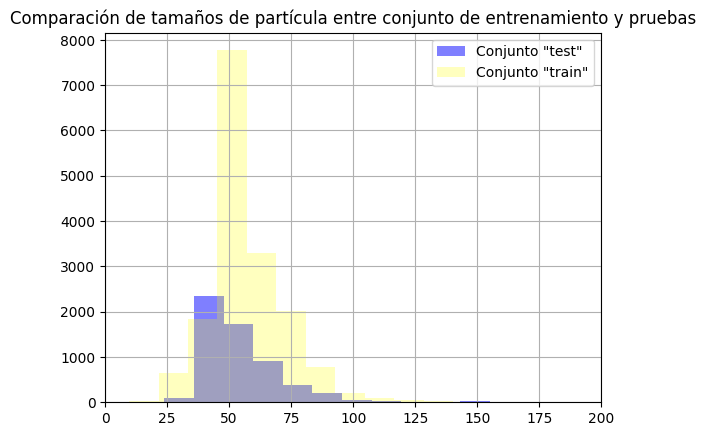

In [22]:
test_size = df_test['rougher.input.feed_size']
train_size = df_train['rougher.input.feed_size']
fig, ax = plt.subplots()
ax.set_title('Comparación de tamaños de partícula entre conjunto de entrenamiento y pruebas')
ax.set_xlim(0, 200)
test_size.hist(
    bins = 40,
    ax=ax,
    color = 'blue',
    alpha = 0.5,
    label = 'Conjunto "test"'
)  
train_size.hist(
    ax=ax,
    bins = 40,
    color = 'yellow',
    alpha = 0.25,
    label = 'Conjunto "train"'
)

plt.legend()
plt.show()

Gráficamente se ve una diferencia entre las distribuciones de ambos conjuntos, pero esto también se debe a la diferencia en la cantidad de datos de cada uno, por lo que compararé sus datos estadísticos

In [23]:
print(test_size.describe())
print(train_size.describe())

count    5856.000000
mean       55.930648
std        22.681798
min         0.046369
25%        43.898467
50%        50.109024
75%        61.608216
max       477.445473
Name: rougher.input.feed_size, dtype: float64
count    16860.000000
mean        58.563359
std         23.635551
min          9.659576
25%         47.597875
50%         54.104257
75%         64.587648
max        484.967466
Name: rougher.input.feed_size, dtype: float64



| Métrica | Test | Train | Diferencia |
|---------|------|-------|------------|
| Media   | 55.93 | 58.56 | 2.63 |
| STD     | 22.68 | 23.63 | 0.95 |
| Min     | 0.04 | 9.65 | 9.61 |
| Mediana | 50.10 | 54.10 | 4 |
| Máx     | 477.44 | 484.96 | 7.52 |


Vemos variaciones pequeñas en todas las estadísticas, unicamente me genera un poco de ruido la diferencia en los datos mínimos entre ambos conjuntos, 'test' tiene un mínio de 0.04  'train' de 9.65, sin embargo si comparamos con el tamaño total del proceso que tiene un máximo de 484.96 esa cantidad representa un porcentaje de 1.98%, por lo que considero que la diferencia es mínima y podemos afirmar que no hay variación significativa entre los conjuntos. Otra posible explicación es que ese mínimo provenga de algún valor atípico, observando la gráfica veo que ni siquiera se aprecian valores, por lo que la frecuencia debe ser muy pequeña.

Sigo ahora con el proceso de 'primary_cleaner'

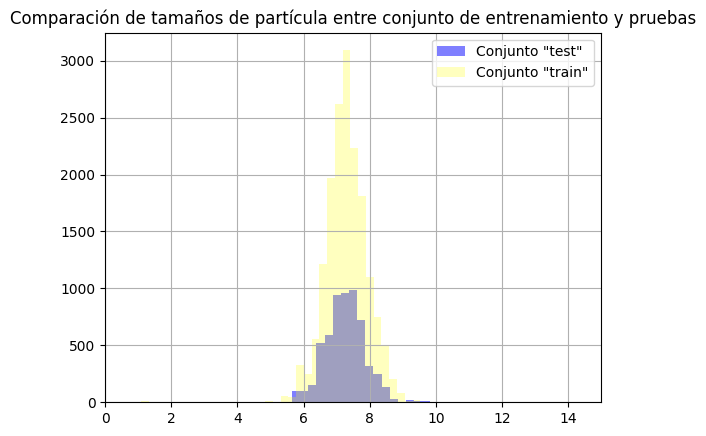

In [24]:
test_size = df_test['primary_cleaner.input.feed_size']
train_size = df_train['primary_cleaner.input.feed_size']
fig, ax = plt.subplots()
ax.set_title('Comparación de tamaños de partícula entre conjunto de entrenamiento y pruebas')
ax.set_xlim(0, 15)
test_size.hist(
    bins = 40,
    ax=ax,
    color = 'blue',
    alpha = 0.5,
    label = 'Conjunto "test"'
)  
train_size.hist(
    ax=ax,
    bins = 40,
    color = 'yellow',
    alpha = 0.25,
    label = 'Conjunto "train"'
)

plt.legend()
plt.show()

En este caso vemos gráficas con prácticamente la misma distribución a la vista, la diferencia en tamaños es debido a la cantidad de datos de cada conjunto. Siguiendo lo hecho para el caso anterior, analizaré los datos estadísticos de cada conjunto:

In [25]:
print(test_size.describe())
print(train_size.describe())

count    5856.000000
mean        7.264651
std         0.611526
min         5.650000
25%         6.885625
50%         7.259333
75%         7.650000
max        15.500000
Name: primary_cleaner.input.feed_size, dtype: float64
count    16860.000000
mean         7.297285
std          0.619166
min          1.080000
25%          6.940000
50%          7.285000
75%          7.700000
max         10.470000
Name: primary_cleaner.input.feed_size, dtype: float64


| Métrica | Test | Train | Diferencia |
|---------|------|-------|------------|
| Media   | 7.26 | 7.29 | 0.03 |
| STD     | 0.61 | 0.61 | 0.00 |
| Min     | 5.65 | 1.08 | 4.57 |
| Mediana | 7.25 | 7.28 | 0.03 |
| Máx     | 15.50 | 10.47 | 5.03 |

Vemos que la media y la mediana son aún más cercanas que para el caso anterior, la desviación estandar es prácticamente igual en ambos conjuntos (diferencia po decimales). Con todo esto, puedo afirmar que para este caso también son comparables los conjuntos, no hay una variación significativa que indique que el modelo pueda tener algún error.

### 2.3. Análisis de concentraciones totales en todas las etapas

Voy a calcular primero la concentración total por cada etapa, para esto sumo los valores de todos los elementos en la materia prima y en las salidas de cada proceso.

In [26]:
filas_materia_prima = [col for col in df_full.columns if 'rougher' in col and 'input' in col and 'calculation' not in col]
filas_rougher_concentrate = [col for col in df_full.columns if 'rougher' in col and 'concentrate' in col and 'calculation' not in col]
filas_final_concentrate = [col for col in df_full.columns if 'final' in col and 'concentrate' in col and 'calculation' not in col]

materia_prima = pd.Series(df_full[filas_materia_prima].sum(axis = 1))
rougher_concentrate = pd.Series(df_full[filas_rougher_concentrate].sum(axis = 1))
final_concentrate = pd.Series(df_full[filas_final_concentrate].sum(axis = 1))


concentracion_etapas = pd.DataFrame({
    'materia_prima': materia_prima,
    'rougher_concentrate': rougher_concentrate,
    'final_concentrate': final_concentrate
})

print(concentracion_etapas.head())

                     materia_prima  rougher_concentrate  final_concentrate
date                                                                      
2016-01-15 00:00:00     666.550126            66.424950          63.644396
2016-01-15 01:00:00     669.214076            67.012710          63.957723
2016-01-15 02:00:00     674.390106            66.103793          64.311180
2016-01-15 03:00:00     687.166969            65.752751          63.573449
2016-01-15 04:00:00     678.750244            65.908382          64.004667


Una vez teniendo un dataframe nuevo con los datos, reviso la salida de describe para identificar si existen datos atípicos

In [27]:
print(concentracion_etapas.describe())

       materia_prima  rougher_concentrate  final_concentrate
count   22716.000000         22716.000000       22716.000000
mean      572.352903            61.378090          62.166910
std       201.901651            23.558863          20.954107
min         0.000000             0.000000           0.000000
25%       522.121531            63.263228          67.005682
50%       628.524318            69.399690          69.230638
75%       700.105898            74.015593          71.127337
max      1019.617886            90.964431          80.210644


Veo que hay al menos 1 fila con valores de concentración 0, lo cual no puede ser en la realidad, por lo que primero filtro esos valores para despues eliminarlos en la variable 'concentracion_etapas' para visualizar la información estadística, luego si todo cuadra eliminaré los index con datos extraños de los dfs 'train' y 'test'

In [28]:
indexes = concentracion_etapas[(concentracion_etapas['materia_prima'] == 0) | (concentracion_etapas['rougher_concentrate'] == 0) | (concentracion_etapas['final_concentrate'] == 0)].index
concentracion_etapas = concentracion_etapas.drop(indexes, axis = 0)
print(concentracion_etapas.describe())

       materia_prima  rougher_concentrate  final_concentrate
count   20429.000000         20429.000000       20429.000000
mean      613.852444            67.595860          67.284295
std       145.984262            13.850722          11.569780
min        15.582571             0.039898           0.040000
25%       547.040854            65.784679          67.721384
50%       641.220161            70.146424          69.487403
75%       706.132963            74.485457          71.279801
max      1019.617886            90.964431          80.210644


Hay muchas posibilidades por las cuales estas columnas pueden tener valores en 0, siendo una de ellas un paro productivo en la planta de producción, este tipo de condiciones no son normales, y no es del interés del modelo que quiero desarrollar el predecir resultados cuando la planta está parada, por lo que mi decisión es eliminar estas filas para evitar ruido en mis datos.

Como en este momento no se si los index con los datos a eliminar se encuentran en 'train' o 'test' procedo a aplicar .drop en ambos pero usando el parámetro error='ignore' para que ignore cuando un index no se encuentra en el df en cuestión.

In [29]:
df_test = df_test.drop(indexes, axis = 0, errors = 'ignore')
df_train = df_train.drop(indexes, axis = 0, errors = 'ignore')

## 3. Construcción y entrenamiento del modelo

### 3.1. Función para el cálculo de sMAPE por proceso y sMAPE final

In [30]:
def sMAPE(target, predictions): # Evito usar un ciclo for para ahorrar tiempo de ejecución, la sumatoria entre el número de datos es el cálculo de la media
    return 100 * np.mean(np.abs(target - predictions) / ((np.abs(target) + np.abs(predictions)) / 2))


In [31]:
def sMAPE_general(sMAPE_rougher, sMAPE_final):
    return (0.25 * sMAPE_rougher) + (0.75 * sMAPE_final)

### 3.2. Construcción y entrenamiento de modelo

Con los datos listo para procesar, separo en features y target para el futuro entrenamiento del modelo. Las columnas presentes en el conjunto 'test' son features, la recuperación sería nuestro target.

In [32]:
features_test = df_test
features_train = df_train[df_test.columns]

target_rougher_train = df_train['rougher.output.recovery']
target_rougher_test=df_full.loc[df_test.index, 'rougher.output.recovery']
target_final_train = df_train['final.output.recovery']
target_final_test=df_full.loc[df_test.index, 'final.output.recovery']

#### Arbol de decisión

Crearé funciones para el entrenamiento de los modelos

In [33]:
def arbol_decision(profundidad, features, target):
    '''
    Evalúa un DecisionTreeRegressor con validación cruzada (k=5) para un rango
    de valores de max_depth, y regresa la profundidad con mejor desempeño según sMAPE.

    Para cada valor de profundidad en 'profundidad':
        1. Crea un DecisionTreeRegressor con ese max_depth (random_state=12345 fijo
           para reproducibilidad).
        2. Corre cross_val_score con 5 folds, usando smape_scorer (definido fuera
           de esta función) para evaluar el desempeño.
        3. Promedia los 5 resultados del fold y los guarda (en positivo, ya que
           smape_scorer regresa el score negado por greater_is_better=False).

    Al final, busca el índice de la profundidad con el sMAPE promedio más bajo
    (mejor desempeño) y lo regresa junto con su valor de sMAPE.

    Parámetros:
        profundidad (range o list): valores de max_depth a probar.
        features (DataFrame): conjunto de features (ej. features_train).
        target (Series): variable objetivo (ej. target_rougher_train o target_final_train).

    Regresa:
        tuple: (mejor_max_depth, mejor_sMAPE)
        '''

    resultados_por_profundidad = []

    for depth in profundidad:
        model = DecisionTreeRegressor(max_depth=depth, random_state=12345)
        resultados = cross_val_score(model, features, target, cv=5, scoring=smape_scorer)
        resultados_por_profundidad.append(-resultados.mean())
    return profundidad[np.argmin(resultados_por_profundidad)], min(resultados_por_profundidad)

In [34]:
smape_scorer = make_scorer(sMAPE, greater_is_better=False) # Creamos el método de evaluación para nuestro modelo

mejor_profundidad_rougher, sMAPE_rougher = arbol_decision(range(1,51), features_train, target_rougher_train)
print(f'Mejor profundidad para el proceso "rougher": {mejor_profundidad_rougher}, se tuvo un sMAPE de: {sMAPE_rougher}')

Mejor profundidad para el proceso "rougher": 5, se tuvo un sMAPE de: 7.978512376677594


In [35]:
mejor_profundidad_final, sMAPE_final = arbol_decision(range(1,51), features_train, target_final_train)
print(f'Mejor profundidad para el proceso "final": {mejor_profundidad_final}, se tuvo un sMAPE de: {sMAPE_final}')

Mejor profundidad para el proceso "final": 3, se tuvo un sMAPE de: 10.367443239448557


#### Bosque Aleatorio

In [36]:
def bosque_aleatorio(profundidad, arboles, features, target):
    """
    Evalúa un RandomForestRegressor con validación cruzada (k=5) para todas las
    combinaciones de max_depth y n_estimators (búsqueda tipo grid search manual),
    y regresa la combinación con mejor desempeño según sMAPE.

    Para cada combinación (estimator, depth) de 'arboles' x 'profundidad':
        1. Crea un RandomForestRegressor con 
esos hiperparámetros (random_state=12345
           fijo para reproducibilidad).
        2. Corre cross_val_score con 5 folds, usando smape_scorer (definido fuera
           de esta función) para evaluar el desempeño.
        3. Promedia los 5 resultados del fold, los guarda en positivo (ya que
           smape_scorer regresa el score negado por greater_is_better=False),
           y guarda también la combinación (estimator, depth) correspondiente
           en 'combinaciones', en el mismo orden, para poder identificarla después.

    Al final, busca el índice del sMAPE promedio más bajo (mejor desempeño) y
    usa ese mismo índice tanto en 'resultados' como en 'combinaciones' para
    recuperar la combinación exacta de hiperparámetros que lo produjo.

    Parámetros:
        profundidad (range o list): valores de max_depth a probar.
        arboles (range o list): valores de n_estimators a probar.
        features (DataFrame): conjunto de features (ej. features_train).
        target (Series): variable objetivo (ej. target_rougher_train o target_final_train).

    Regresa:
        tuple: (mejor_n_estimators, mejor_max_depth, mejor_sMAPE)
    """

    resultados = []
    combinaciones = []
    for estimator in arboles:
        for depth in profundidad:
            model = RandomForestRegressor(n_estimators=estimator, max_depth=depth, random_state=12345)
            score = cross_val_score(model, features, target, cv=5, scoring=smape_scorer)
            resultados.append(-score.mean())
            combinaciones.append((estimator, depth))

    mejor_idx = np.argmin(resultados)
    mejor_estimator, mejor_depth = combinaciones[mejor_idx]
    return mejor_estimator, mejor_depth, resultados[mejor_idx]


Una vez creada la función, creo modelos que oscilan entre 1-100 arboles con profundidades de 1-10

In [37]:
mejor_estimator_rougher, mejor_depth_rougher, sMAPE_rougher_bosque = bosque_aleatorio(range(1,11), range(1,51,10), features_train, target_rougher_train)
print(f'Los mejores resultados para el proceso "rougher" se obtuvieron con los siguientes parámetros: Profundidad: {mejor_depth_rougher}, árboles: {mejor_estimator_rougher} se tuvo un sMAPE de: {sMAPE_rougher_bosque}')

Los mejores resultados para el proceso "rougher" se obtuvieron con los siguientes parámetros: Profundidad: 6, árboles: 41 se tuvo un sMAPE de: 7.246848826002155


In [38]:
mejor_estimator_final, mejor_depth_final, sMAPE_final_bosque = bosque_aleatorio(range(1,11), range(1,51,10), features_train, target_final_train)
print(f'Los mejores resultados para el proceso "final" se obtuvieron con los siguientes parámetros: Profundidad: {mejor_depth_final}, árboles: {mejor_estimator_final} se tuvo un sMAPE de: {sMAPE_final_bosque}')

Los mejores resultados para el proceso "final" se obtuvieron con los siguientes parámetros: Profundidad: 5, árboles: 21 se tuvo un sMAPE de: 9.706795270437969


#### Regresión lineal

In [39]:
def regresion_lineal(features, target):
    """
    Evalúa un LinearRegression con validación cruzada (k=5) y regresa su
    desempeño según sMAPE.

    A diferencia de arbol_decision() y bosque_aleatorio(), esta función no
    itera sobre hiperparámetros, ya que LinearRegression no tiene parámetros
    de complejidad que ajustar (como max_depth o n_estimators); solo entrena
    y evalúa el modelo una vez.

    Pasos:
        1. Crea un LinearRegression (sin hiperparámetros que fijar).
        2. Corre cross_val_score con 5 folds, usando smape_scorer (definido
           fuera de esta función) para evaluar el desempeño.
        3. Promedia los 5 resultados del fold (en positivo, ya que
           smape_scorer regresa el score negado por greater_is_better=False).

    Parámetros:
        features (DataFrame): conjunto de features (ej. features_train).
        target (Series): variable objetivo (ej. target_rougher_train o target_final_train).

    Regresa:
        float: sMAPE promedio de los 5 folds.
    """
    model = LinearRegression()
    resultados = cross_val_score(model, features, target, cv=5, scoring=smape_scorer)
    return -resultados.mean()

In [40]:
sMAPE_regresion_rougher = regresion_lineal(features_train, target_rougher_train)
print(f'sMAPE para el proceso "rougher" con regresión lineal: {sMAPE_regresion_rougher}')

sMAPE_regresion_final = regresion_lineal(features_train, target_final_train)
print(f'sMAPE para el proceso "final" con regresión lineal: {sMAPE_regresion_final}')

sMAPE para el proceso "rougher" con regresión lineal: 7.2608044658642825
sMAPE para el proceso "final" con regresión lineal: 12.681696290807121


#### Cálculo de sMAPE final con los mejores parámetros para cada modelo

In [42]:
'''def sMAPE_general(sMAPE_rougher, sMAPE_final):
    return (0.25 * sMAPE_rougher) + (0.75 * sMAPE_final)
'''

resultados_arbol = sMAPE_general(sMAPE_rougher, sMAPE_final)
resultados_bosque = sMAPE_general(sMAPE_rougher_bosque, sMAPE_final_bosque)
resultados_regresion = sMAPE_general(sMAPE_regresion_rougher, sMAPE_regresion_final)

print(f'Árbol de decisión: {resultados_arbol}')
print(f'Bosque aleatorio: {resultados_bosque}')
print(f'Regresión lineal: {resultados_regresion}')

Árbol de decisión: 9.770210523755816
Bosque aleatorio: 9.091808659329015
Regresión lineal: 11.32647333457141


#### Resultados de los modelos

Se entrenaron y evaluaron tres modelos de regresión mediante validación cruzada de 5 folds, usando sMAPE como métrica individual por proceso y el sMAPE general ponderado (0.25 × rougher + 0.75 × final) como criterio de comparación:

| Modelo | Hiperparámetros (rougher) | Hiperparámetros (final) | sMAPE rougher | sMAPE final | sMAPE general |
|--------|---------------------------|-------------------------|---------------|-------------|---------------|
| Árbol de decisión | max_depth = 5 |	max_depth = 3	| 7.98	| 10.37| 	9.77 |
| Bosque aleatorio | n_estimators = 41, max_depth = 6 |	n_estimators = 21, max_depth = 5 |	7.25 |	9.71 |	9.09 |
| Regresión lineal | — |	—	| 7.26	| 12.68	| 11.32 |

El bosque aleatorio obtuvo el menor sMAPE general (9.09), superando tanto al árbol de decisión como a la regresión lineal en ambos procesos. La regresión lineal, aunque competitiva en el proceso rougher, mostró una degradación notable en el proceso final, sugiriendo una relación no puramente lineal entre las variables de entrada y la recuperación. Con base en estos resultados, se selecciona el bosque aleatorio como modelo final.

#### Validación del modelo con el conjunto de prueba

Ya teniendo los parámetros del modelo que mejores resultados dio, hago la validación con el conjunto 'test' 

In [44]:
#def sMAPE(target, predictions):
model_rougher = RandomForestRegressor(n_estimators=41, max_depth=6, random_state=12345)
model_rougher.fit(features_train, target_rougher_train)
predictions_rougher = model_rougher.predict(features_test)
sMAPE_rougher_elegido = sMAPE(target_rougher_test, predictions_rougher)
print(f'El resultado de sMAPE para el proceso "rougher" con el modelo elegido es de: {sMAPE_rougher_elegido}')

model_final = RandomForestRegressor(n_estimators=21, max_depth=5, random_state=12345)
model_final.fit(features_train, target_final_train)
predictions_final = model_final.predict(features_test)
sMAPE_final_elegido = sMAPE(target_final_test, predictions_final)
print(f'El resultado de sMAPE para el proceso "final" con el modelo elegido es de: {sMAPE_final_elegido}')

sMAPE_definitivo = sMAPE_general(sMAPE_rougher_elegido, sMAPE_final_elegido)
print(f'El resultado de sMAPE ponderado (25% rougher y 75% final) es de: {sMAPE_definitivo}')

El resultado de sMAPE para el proceso "rougher" con el modelo elegido es de: 4.74869341070715
El resultado de sMAPE para el proceso "final" con el modelo elegido es de: 8.304834321954038
El resultado de sMAPE ponderado (25% rougher y 75% final) es de: 7.415799094142316


#### Validación vs modelo 'dummy'

In [47]:
# Modelo dummy para rougher
dummy_rougher = DummyRegressor(strategy='mean')
dummy_rougher.fit(features_train, target_rougher_train)
predicciones_dummy_rougher = dummy_rougher.predict(features_test)
smape_dummy_rougher = sMAPE(target_rougher_test, predicciones_dummy_rougher)

# Modelo dummy para final
dummy_final = DummyRegressor(strategy='mean')
dummy_final.fit(features_train, target_final_train)
predicciones_dummy_final = dummy_final.predict(features_test)
smape_dummy_final = sMAPE(target_final_test, predicciones_dummy_final)

# sMAPE general del dummy
smape_dummy_general = sMAPE_general(smape_dummy_rougher, smape_dummy_final)

print(f'sMAPE dummy (rougher): {smape_dummy_rougher}')
print(f'sMAPE dummy (final): {smape_dummy_final}')
print(f'sMAPE dummy (general): {smape_dummy_general}')

sMAPE dummy (rougher): 5.504679353072951
sMAPE dummy (final): 8.26607242805277
sMAPE dummy (general): 7.575724159307815


#### Conclusiones de validación contra modelo dummy

Para confirmar que el modelo seleccionado (bosque aleatorio) aprende patrones reales
y no simplemente replica el promedio del target, se comparó su desempeño contra un
`DummyRegressor` (estrategia `mean`) entrenado y evaluado bajo las mismas condiciones:

| Métrica         | Bosque aleatorio | Dummy (mean) |
|-----------------|------------------|--------------|
| sMAPE rougher   | 4.75             | 5.50         |
| sMAPE final     | 8.30             | 8.27         |
| sMAPE general   | **7.42**         | 7.58         |

El bosque aleatorio superó al modelo dummy en el sMAPE general (7.42 vs 7.58), 
confirmando que aporta valor predictivo por encima de una estimación ingenua. 
Sin embargo, esta ventaja proviene casi en su totalidad del proceso rougher, donde 
la mejora es clara (5.50 → 4.75). En el proceso final —que tiene mayor peso en la 
métrica combinada (75%)— el modelo y el dummy obtuvieron un desempeño prácticamente 
idéntico (8.30 vs 8.27), lo que sugiere que predecir `final.output.recovery` es 
considerablemente más difícil con las features disponibles, y que hay margen para 
explorar mejoras futuras (más ingeniería de características, otros algoritmos, o 
ajuste más fino de hiperparámetros) enfocadas específicamente en esa etapa del proceso.

## Fine tuning 

Ya que la diferencia entre el modelo elegido y el dummy no es muy grande, voy a hacer un ajuste fino de los parámetros del bosque aleatorio para mejorar el resultado

In [51]:
mejor_estimator_fine, mejor_depth_fine, sMAPE_fine = bosque_aleatorio(range(4,8), range(18,22), features_train, target_final_train)
print(f'Los mejores resultados para el proceso "final" se obtuvieron con los siguientes parámetros: Profundidad: {mejor_depth_fine}, árboles: {mejor_estimator_fine} se tuvo un sMAPE de: {sMAPE_fine}')

Los mejores resultados para el proceso "final" se obtuvieron con los siguientes parámetros: Profundidad: 5, árboles: 21 se tuvo un sMAPE de: 9.706795270437969


# Conclusión general

Se entrenaron y evaluaron tres modelos de regresión (árbol de decisión, bosque aleatorio y regresión lineal) para predecir la recuperación de oro en las etapas rougher y final del proceso de flotación, usando sMAPE ponderado (25% rougher, 75% final) como métrica de comparación:

| Modelo | Hiperparámetros (rougher) | Hiperparámetros (final) | sMAPE rougher | sMAPE final | sMAPE general |
|---|---|---|---|---|---|
| Árbol de decisión | max_depth=5 | max_depth=3 | 7.98 | 10.37 | 9.77 |
| **Bosque aleatorio** | n_estimators=41, max_depth=6 | n_estimators=21, max_depth=5 | 7.25 | 9.71 | **9.09** |
| Regresión lineal | — | — | 7.26 | 12.68 | 11.33 |

**Modelo elegido:** el bosque aleatorio, por obtener el menor sMAPE general en validación cruzada y mantener un desempeño consistente en ambos procesos. Evaluado sobre el conjunto de prueba, obtuvo un sMAPE de 4.75 (rougher), 8.30 (final) y 7.42 (general).

**Validación contra dummy:** comparado contra un `DummyRegressor` (estrategia mean), el bosque aleatorio superó al dummy en sMAPE general (7.42 vs 7.58), confirmando que el modelo aporta valor predictivo real y no equivale a una estimación ingenua. Sin embargo, esa ventaja es modesta y proviene casi en su totalidad del proceso rougher (5.50 → 4.75), mientras que en el proceso final el modelo prácticamente empató con el dummy (8.27 vs 8.30).

**Por qué el modelo de rougher funciona mejor que el de final:** esta diferencia no es un problema de ajuste de hiperparámetros, sino una limitación estructural de los datos disponibles en el momento de la predicción. Las variables `output` y `calculation` — que son las más informativas sobre el estado de cada etapa, ya que son resultado directo de los procesos químicos y mediciones de laboratorio — solo se conocen *después* de que cada etapa ocurre, por lo que no están disponibles en el conjunto de prueba (tal como se identificó en el punto 1.3). El modelo de `final.output.recovery` depende de una cadena más larga de etapas intermedias (rougher → primary cleaner → secondary cleaner → final) que la de `rougher.output.recovery`, y en cada una de esas etapas se pierde la información más predictiva. Como evidencia adicional, realicé un ajuste fino de los parámetros, llegando a la misma combinación (21 árboles, profundidad 5), lo que sugiere que el modelo ya alcanzó el límite de lo que puede aprender con la información disponible — el techo no está en el algoritmo, sino en los datos con los que puede contar al momento de predecir.

**Conclusión:** se selecciona el bosque aleatorio como modelo final del proyecto. Su desempeño en el proceso rougher es sólido y claramente superior al dummy; su desempeño en el proceso final, aunque técnicamente mejor que adivinar el promedio, está limitado por la naturaleza del problema más que por el modelo en sí. Futuras mejoras deberían enfocarse no en ajustar más el modelo, sino en obtener o derivar nuevas variables disponibles *antes* del proceso (por ejemplo, características de los inputs y de los reactivos) que puedan servir como proxy de la información que hoy solo se conoce después del hecho.

Proceso tecnológico
¿Cómo se extrae el oro del mineral? Veamos las etapas de este proceso.

El mineral extraído se somete a un tratamiento primario para obtener la mezcla de mineral, o alimentación rougher, que es la materia prima utilizada para la flotación (también conocida como proceso rougher). Después de la flotación, el material se somete al proceso de purificación en dos etapas.

image

Veamos el proceso paso a paso:

1. Flotación

La mezcla de mineral de oro se introduce en las plantas de flotación para obtener un concentrado de oro rougher y colas rougher (es decir, residuos del producto con una baja concentración de metales valiosos).

La estabilidad de este proceso se ve afectada por la volatilidad y el estado físico-químico desfavorable de la pulpa de flotación (una mezcla de partículas sólidas y líquido).

2. Purificación

El concentrado rougher se somete a dos etapas de purificación. Tras esto, tenemos el concentrado final y las nuevas colas.
Descripción de datos

Proceso tecnológico

    Rougher feed: materia prima
    Rougher additions (o adiciones de reactivos): reactivos de flotación: xantato, sulfato, depresante
        Xantato: promotor o activador de la flotación
        Sulfato: sulfuro de sodio para este proceso en particular
        Depresante: silicato de sodio
    Rougher process: flotación
    Rougher tails: residuos del producto
    Float banks: instalación de flotación
    Cleaner process: purificación
    Rougher Au: concentrado de oro rougher
    Final Au: concentrado de oro final

Parámetros de las etapas

    air amount: volumen de aire
    fluid levels
    feed size: tamaño de las partículas de la alimentación
    feed rate

Denominación de las características

Así es como se denominan las características:

[stage].[parameter_type].[parameter_name]

Ejemplo: rougher.input.feed_ag

Valores posibles para [stage]:

    rougher: flotación
    primary_cleaner: purificación primaria
    secondary_cleaner: purificación secundaria
    final: características finales

Valores posibles para [parameter_type]:

    input: parámetros de la materia prima
    output: parámetros del producto
    state: parámetros que caracterizan el estado actual de la etapa
    calculation: características de cálculo

image
Cálculo de la recuperación

La recuperación del oro puede calcularse en distintas etapas del proceso. 

Para ello, se utiliza la siguiente fórmula:

image

donde:

    C es la proporción de oro en el concentrado de la etapa analizada;
    F es la proporción de oro en la alimentación de esa etapa;
    T es la proporción de oro en las colas de esa etapa.

La interpretación exacta de estas variables depende de la etapa del proceso para la que se calcule la recuperación.
Recuperación del concentrado rougher

Para calcular la recuperación del concentrado rougher (rougher.output.recovery), las variables corresponden a las siguientes columnas:

    C = Proporción de oro en el concentrado rougher, justo después de la flotación (rougher.output.concentrate_au)
    F = Proporción de oro en la alimentación rougher, antes de la flotación (rougher.input.feed_au)
    T = Proporción de oro en las colas rougher, justo después de la flotación (rougher.output.tail_au)

Recuperación del concentrado final

La misma fórmula puede aplicarse a la etapa final del proceso. 

En ese caso:

    C = Proporción de oro en el concentrado final
    F = Proporción de oro en la alimentación de la etapa final
    T = Proporción de oro en las colas de la etapa final

En todos los casos, la recuperación se calcula a partir de la proporción de oro en la alimentación, el concentrado y las colas de la etapa correspondiente.
Métricas de evaluación

Para resolver el problema, necesitaremos una nueva métrica. Se llama sMAPE, o error medio absoluto porcentual simétrico.

Es similar al MAE, pero se expresa en valores relativos en lugar de absolutos. ¿Por qué es simétrico? Porque tiene en cuenta la escala tanto del objetivo como de la predicción.

Así es como se calcula el sMAPE:

image

Designación:

image

    Valor del objetivo para la observación con el índice i en el conjunto utilizado para medir la calidad.

image

    Valor de la predicción para la observación con el índice i, por ejemplo, en la muestra de prueba.

image

    Número de observaciones de la muestra.

image

    Suma de todas las observaciones de la muestra (i toma valores de 1 a N).

Necesitamos predecir dos valores:

    La recuperación del concentrado rougher rougher.output.recovery.
    La recuperación final del concentrado final.output.recovery.

La métrica final incluye los dos valores:

image